In [1]:
# Cell 1: 匯入套件

# 載入函式庫
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# 匯入資料集與模型建構所需模組
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Add
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation, Add,
    GlobalAveragePooling2D, Dense, Dropout
)

2026-04-23 09:49:43.738868: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-23 09:49:43.970035: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-23 09:49:44.014592: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-23 09:49:44.626375: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: li

正在載入 CIFAR-100 資料集...
訓練集影像: (50000, 32, 32, 3)
測試集影像: (10000, 32, 32, 3)


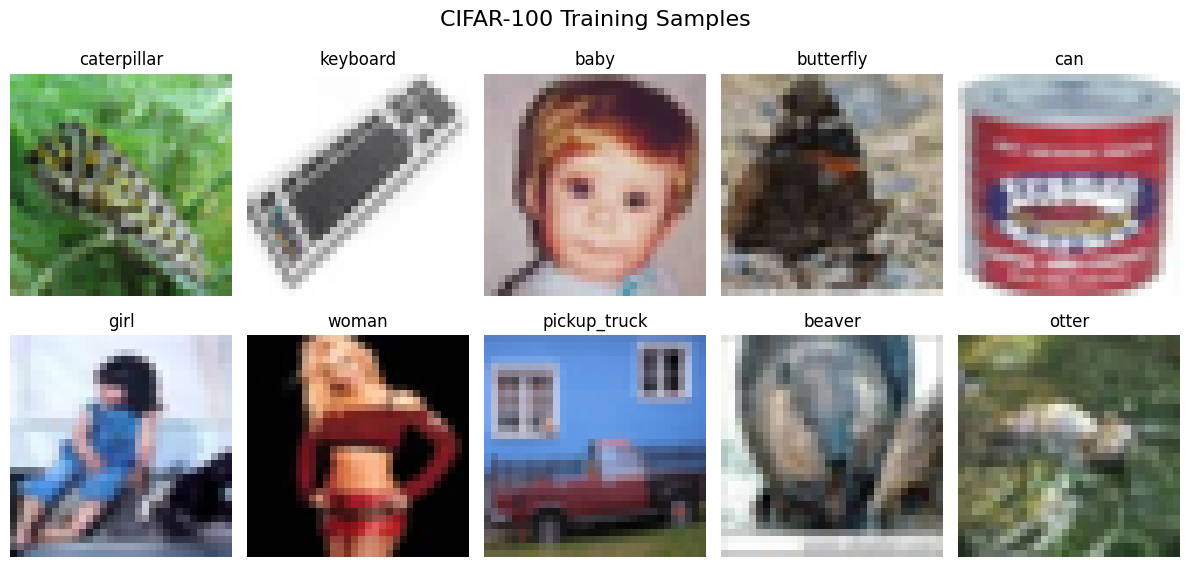

In [2]:
# Cell 2: 載入與預處理 CIFAR-100 資料S
print("正在載入 CIFAR-100 資料集...")
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')

# 1. 影像正規化 (Normalization)
# 將像素值從 0~255 縮放到 0~1 之間
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 2. 標籤 One-hot Encoding
num_classes = 100
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print(f"訓練集影像: {x_train.shape}")
print(f"測試集影像: {x_test.shape}")

cifar100_labels = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle',
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel',
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock',
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster',
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose',
    'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
    'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
    'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

def show_sample_images(images, labels, num=10):
    rows = 2
    cols = num // rows
    plt.figure(figsize=(12, 6))
    indices = np.random.choice(range(len(images)), num)

    for i, idx in enumerate(indices):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[idx])

        label_id = labels[idx][0]
        label_name = cifar100_labels[label_id]

        plt.title(f"{label_name}", fontsize=12)
        plt.axis('off')

    plt.suptitle("CIFAR-100 Training Samples", fontsize=16)
    plt.tight_layout()
    plt.show()

# 呼叫函數顯示圖片
show_sample_images(x_train, y_train, num=10)

In [7]:
# Cell 3: 定義模型結構
def build_resnet():
    ### [可自行更改] 輸入圖片大小 (CIFAR 預設為 32x32x3) ###
    inputs = Input(shape=(32, 32, 3))

    # === 1. 初始卷積層 ===
    ### [可自行更改] 卷積核數量 (filters)、卷積核大小 (kernel_size) ###
    # x = Conv2D(filters=64, kernel_size=(7, 7), padding='same',
    #         kernel_regularizer=l2(1e-4))(inputs)
    x = Conv2D(filters=128, kernel_size=(3, 3), padding='same',
            kernel_regularizer=l2(1e-4))(inputs)
    x = BatchNormalization()(x)
    x = Activation('leaky_relu')(x)

    # === 2. 殘差區塊 (Residual Block) ===

    # === 第 1.1 層 ===
    # x = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same')(x)
    # 儲存原始特徵，稍後要與卷積後的結果相加
    shortcut = x
    ### [可自行更改] 這裡的 filters 數量必須與 shortcut 一致才能相加 ###
    fx = Conv2D(filters=128, kernel_size=(3, 3), padding='same', kernel_regularizer=l2(1e-4))(x)
    fx = BatchNormalization()(fx)
    fx = Activation('leaky_relu')(fx)
    fx = Conv2D(filters=128, kernel_size=(3, 3), padding='same', kernel_regularizer=l2(1e-4))(fx)
    fx = BatchNormalization()(fx)
    # 將兩條路徑相加 (Skip Connection)
    x = Add()([shortcut, fx])
    x = tf.keras.activations.relu(x)
    # === 第 1.2 層 ===
    # 儲存原始特徵，稍後要與卷積後的結果相加
    shortcut = x
    ### [可自行更改] 這裡的 filters 數量必須與 shortcut 一致才能相加 ###
    fx = Conv2D(filters=128, kernel_size=(3, 3), padding='same', kernel_regularizer=l2(1e-4))(x)
    fx = BatchNormalization()(fx)
    fx = Activation('leaky_relu')(fx)
    fx = Conv2D(filters=128, kernel_size=(3, 3), padding='same', kernel_regularizer=l2(1e-4))(fx)
    fx = BatchNormalization()(fx)
    # 將兩條路徑相加 (Skip Connection)
    x = Add()([shortcut, fx])
    x = tf.keras.activations.relu(x)

    # === 第 2.1 層 ===
    # 儲存原始特徵，稍後要與卷積後的結果相加
    shortcut = Conv2D(filters=256, kernel_size=(1, 1), strides=(2, 2), padding='same', kernel_regularizer=l2(1e-4))(x)
    shortcut = BatchNormalization()(shortcut)
    ### [可自行更改] 這裡的 filters 數量必須與 shortcut 一致才能相加 ###
    fx = Conv2D(filters=256, kernel_size=(3, 3), strides=(2, 2), padding='same', kernel_regularizer=l2(1e-4))(x)
    fx = BatchNormalization()(fx)
    fx = Activation('leaky_relu')(fx)
    fx = Conv2D(filters=256, kernel_size=(3, 3), padding='same', kernel_regularizer=l2(1e-4))(fx)
    fx = BatchNormalization()(fx)
    # 將兩條路徑相加 (Skip Connection)
    x = Add()([shortcut, fx])
    x = tf.keras.activations.relu(x)
    # === 第 2.2 層 ===
    # 儲存原始特徵，稍後要與卷積後的結果相加
    shortcut = x
    ### [可自行更改] 這裡的 filters 數量必須與 shortcut 一致才能相加 ###
    fx = Conv2D(filters=256, kernel_size=(3, 3), padding='same', kernel_regularizer=l2(1e-4))(x)
    fx = BatchNormalization()(fx)
    fx = Activation('leaky_relu')(fx)
    fx = Conv2D(filters=256, kernel_size=(3, 3), padding='same', kernel_regularizer=l2(1e-4))(fx)
    fx = BatchNormalization()(fx)
    # 將兩條路徑相加 (Skip Connection)
    x = Add()([shortcut, fx])
    x = tf.keras.activations.relu(x)

    # === 第 3.1 層 ===
    # 儲存原始特徵，稍後要與卷積後的結果相加
    shortcut = Conv2D(filters=512, kernel_size=(1, 1), strides=(2, 2), padding='same', kernel_regularizer=l2(1e-4))(x)
    shortcut = BatchNormalization()(shortcut)
    ### [可自行更改] 這裡的 filters 數量必須與 shortcut 一致才能相加 ###
    fx = Conv2D(filters=512, kernel_size=(3, 3), strides=(2, 2), padding='same', kernel_regularizer=l2(1e-4))(x)
    fx = BatchNormalization()(fx)
    fx = Activation('leaky_relu')(fx)
    fx = Conv2D(filters=512, kernel_size=(3, 3), padding='same', kernel_regularizer=l2(1e-4))(fx)
    fx = BatchNormalization()(fx)
    # 將兩條路徑相加 (Skip Connection)
    x = Add()([shortcut, fx])
    x = tf.keras.activations.relu(x)
    # === 第 3.2 層
    # 儲存原始特徵，稍後要與卷積後的結果相加
    shortcut = x
    ### [可自行更改] 這裡的 filters 數量必須與 shortcut 一致才能相加 ###
    fx = Conv2D(filters=512, kernel_size=(3, 3), padding='same', kernel_regularizer=l2(1e-4))(x)
    fx = BatchNormalization()(fx)
    fx = Activation('leaky_relu')(fx)
    fx = Conv2D(filters=512, kernel_size=(3, 3), padding='same', kernel_regularizer=l2(1e-4))(fx)
    fx = BatchNormalization()(fx)
    # 將兩條路徑相加 (Skip Connection)
    x = Add()([shortcut, fx])
    x = tf.keras.activations.relu(x)

    # === 第 4.1 層 ===
    # 儲存原始特徵，稍後要與卷積後的結果相加
    shortcut = Conv2D(filters=1024, kernel_size=(1, 1), strides=(2, 2), padding='same', kernel_regularizer=l2(1e-4))(x)
    shortcut = BatchNormalization()(shortcut)
    ### [可自行更改] 這裡的 filters 數量必須與 shortcut 一致才能相加 ###
    fx = Conv2D(filters=1024, kernel_size=(3, 3), strides=(2, 2), padding='same', kernel_regularizer=l2(1e-4))(x)
    fx = BatchNormalization()(fx)
    fx = Activation('leaky_relu')(fx)
    fx = Conv2D(filters=1024, kernel_size=(3, 3), padding='same', kernel_regularizer=l2(1e-4))(fx)
    fx = BatchNormalization()(fx)
    # 將兩條路徑相加 (Skip Connection)
    x = Add()([shortcut, fx])
    x = tf.keras.activations.relu(x)
    # === 第 4.2 層
    # 儲存原始特徵，稍後要與卷積後的結果相加
    shortcut = x
    ### [可自行更改] 這裡的 filters 數量必須與 shortcut 一致才能相加 ###
    fx = Conv2D(filters=1024, kernel_size=(3, 3), padding='same', kernel_regularizer=l2(1e-4))(x)
    fx = BatchNormalization()(fx)
    fx = Activation('leaky_relu')(fx)
    fx = Conv2D(filters=1024, kernel_size=(3, 3), padding='same', kernel_regularizer=l2(1e-4))(fx)
    fx = BatchNormalization()(fx)
    # 將兩條路徑相加 (Skip Connection)
    x = Add()([shortcut, fx])
    x = tf.keras.activations.relu(x)

    # 池化層降維
    x = GlobalAveragePooling2D()(x)

    # === 3. 全連接層與輸出 ===
    # x = Flatten()(x)

    ### [可自行更改] Dense 的神經元數量 (units) ###
    # x = Dense(units=256, activation='relu')(x)

    ### [可自行更改] Dropout 比例 (0.0 ~ 1.0 之間，用來防止過擬合) ###
    x = Dropout(rate=0.4)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs, name="ResNet")
    return model

model = build_resnet()
model.summary()

Model: "ResNet"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 conv2d_40 (Conv2D)             (None, 32, 32, 128)  3584        ['input_3[0][0]']                
                                                                                                  
 batch_normalization_40 (BatchN  (None, 32, 32, 128)  512        ['conv2d_40[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_18 (Activation)     (None, 32, 32, 128)  0           ['batch_normalization_40[0][

In [8]:
# Cell 4: 編譯與訓練
### [可自行更改] 訓練參數 ###
batch_size = 64  # 每次更新梯度的樣本數 (可改為 64, 256 等)
epochs = 500       # 訓練總週期數 (可依時間長短增減)
validation_split = 0.2 # 從訓練集切出多少比例做為驗證集

### [可自行更改] 學習率 (learning_rate) ###
learning_rate = 0.1

# 切分驗證集
split_idx = int(len(x_train) * (1 - validation_split))
x_tr, x_val = x_train[:split_idx], x_train[split_idx:]
y_tr, y_val = y_train_cat[:split_idx], y_train_cat[split_idx:]

# 學習率
step = epochs * (len(x_tr) // batch_size)
learning_rate = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=learning_rate,
    decay_steps=step,
    alpha=0.001
)

### [可自行更改] 選擇優化器 (Optimizer) ###
# optimizer = Adam(learning_rate=learning_rate)

optimizer = SGD(learning_rate=learning_rate, momentum=0.9, nesterov=True)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 資料增強
def cutout(img): # 隨機挖空格 16 * 16
    h, w, _ = img.shape
    mask_size = 16
    
    y = np.random.randint(h)
    x = np.random.randint(w)
    
    y1 = np.clip(y - mask_size // 2, 0, h)
    y2 = np.clip(y + mask_size // 2, 0, h)
    x1 = np.clip(x - mask_size // 2, 0, w)
    x2 = np.clip(x + mask_size // 2, 0, w)
    
    img[y1:y2, x1:x2, :] = 0 
    return img

datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    horizontal_flip=True, # 左右翻轉
    width_shift_range=0.125,
    height_shift_range=0.125,
    fill_mode='reflect',
    preprocessing_function=cutout
)
datagen.fit(x_tr)

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True, verbose=1)

print("開始訓練模型...")
# history = model.fit(x_train, y_train_cat,
#                     batch_size=batch_size,
#                     epochs=epochs,
#                     validation_split=validation_split,
#                     callbacks=[reduce_lr],
#                     verbose=1)
history = model.fit(datagen.flow(x_tr, y_tr, batch_size=batch_size),
                    epochs=epochs,
                    validation_data=(x_val, y_val),
                    callbacks=[early_stop],
                    verbose=1)

開始訓練模型...
Epoch 1/500
625/625 [==============================] - 56s 86ms/step - loss: 5.7960 - accuracy: 0.0382 - val_loss: 5.2738 - val_accuracy: 0.0612
Epoch 2/500
625/625 [==============================] - 52s 82ms/step - loss: 4.9546 - accuracy: 0.0774 - val_loss: 4.6118 - val_accuracy: 0.1131
Epoch 3/500
625/625 [==============================] - 51s 81ms/step - loss: 4.5404 - accuracy: 0.1137 - val_loss: 4.2648 - val_accuracy: 0.1463
Epoch 4/500
625/625 [==============================] - 50s 80ms/step - loss: 4.2112 - accuracy: 0.1469 - val_loss: 4.0281 - val_accuracy: 0.1811
Epoch 5/500
625/625 [==============================] - 50s 80ms/step - loss: 3.9322 - accuracy: 0.1805 - val_loss: 3.6587 - val_accuracy: 0.2273
Epoch 6/500
625/625 [==============================] - 50s 80ms/step - loss: 3.7391 - accuracy: 0.2056 - val_loss: 3.6386 - val_accuracy: 0.2287
Epoch 7/500
625/625 [==============================] - 51s 81ms/step - loss: 3.5783 - accuracy: 0.2289 - val_loss: 3.359

測試集準確率 (Test Accuracy): 0.7513


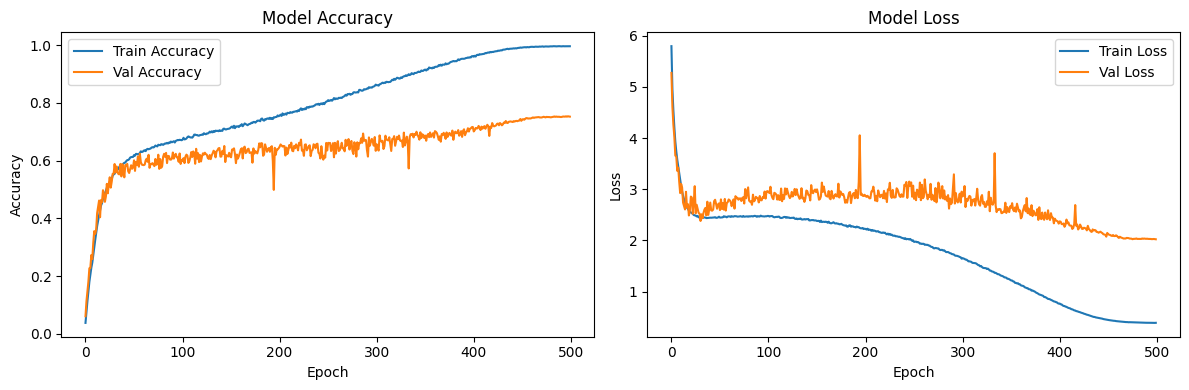

In [9]:
# Cell 5: 繪製訓練結果
# 評估測試集
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"測試集準確率 (Test Accuracy): {test_acc:.4f}")

# 繪圖
plt.figure(figsize=(12, 4))

# 繪製 Accuracy 曲線
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# 繪製 Loss 曲線
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
# Cell 6: 儲存模型
# 將訓練好的模型儲存為 keras 格式
model_name = "cifar100_resnet_midterm.keras"
model.save(model_name)
print(f"模型已成功儲存為: {model_name}")

# 重新載入模型：
# from tensorflow.keras.models import load_model
# loaded_model = load_model(model_name)

模型已成功儲存為: cifar100_resnet_midterm.keras


測試集準確度：0.7513 (75.13%)
CSV 檔案已儲存：mid_113820032_曾靖諺_cifar100_predictions.csv


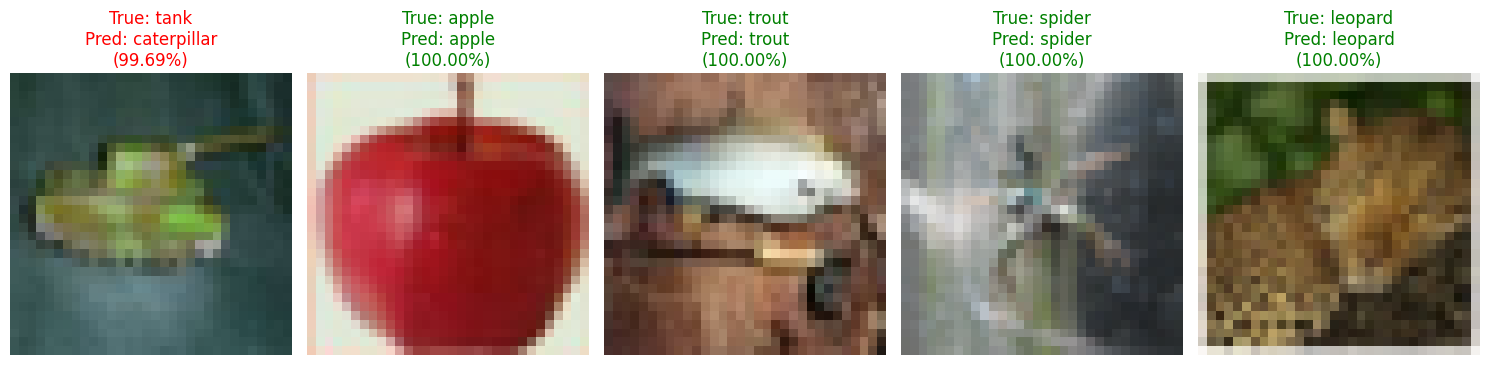

,id,true_label,true_class_name,predict_label,predict_class_name,confidence
0,0,49,mountain,68,road,0.992088
1,1,33,forest,33,forest,1.000000
2,2,72,seal,55,otter,0.992435
3,3,51,mushroom,51,mushroom,1.000000
4,4,71,sea,71,sea,1.000000


In [11]:
# Cell 7: 全部預測 + 顯示準確度 + 存檔 + 隨機抽樣圖片
def evaluate_save_and_plot(model, x_test, y_test, class_names, num_images=5):
    # ===== 1. 預測全部測試資料 =====
    pred_probs = model.predict(x_test, verbose=0)
    pred_labels = np.argmax(pred_probs, axis=1)
    true_labels = np.argmax(y_test, axis=1)
    confidences = np.max(pred_probs, axis=1)

    # ===== 2. 計算整體準確度 =====
    accuracy = np.mean(pred_labels == true_labels)
    print(f"測試集準確度：{accuracy:.4f} ({accuracy:.2%})")

    # ===== 3. 存成 CSV =====
    df = pd.DataFrame({
        "id": np.arange(len(pred_labels)),
        "true_label": true_labels,
        "true_class_name": [class_names[label] for label in true_labels],
        "predict_label": pred_labels,
        "predict_class_name": [class_names[label] for label in pred_labels],
        "confidence": confidences
    })

    # ===== 儲存為csv檔 =====
    file_name = "mid_113820032_曾靖諺_cifar100_predictions.csv"
    df.to_csv(file_name, index=False, encoding="utf-8-sig")
    print(f"CSV 檔案已儲存：{file_name}")

    # ===== 4. 隨機抽樣圖片顯示 =====
    indices = np.random.choice(range(len(x_test)), num_images, replace=False)

    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(indices):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(x_test[idx])

        true_label = true_labels[idx]
        pred_label = pred_labels[idx]
        confidence = confidences[idx]

        title_color = 'green' if pred_label == true_label else 'red'
        plt.title(
            f"True: {class_names[true_label]}\n"
            f"Pred: {class_names[pred_label]}\n"
            f"({confidence:.2%})",
            color=title_color
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    return df, accuracy

# 執行
df_result, test_acc = evaluate_save_and_plot(
    model=model,
    x_test=x_test,
    y_test=y_test_cat,
    class_names=cifar100_labels,
    num_images=5
)

df_result.head()